# Projet Traitement des Signaux - Analyse d’image

## Objectif

Le but de ce projet est d’analyser une image bruitée contenant plusieurs voitures colorées.  
Le travail consiste à afficher les composantes RGB, étudier les histogrammes, isoler les voitures vertes puis détecter leurs bounding boxes.

In [51]:
print("Projet traitement image groupe G")

Projet traitement image groupe G


In [52]:
# Bibliothèque pour les calculs numériques et les tableaux
import numpy as np

# Bibliothèque pour l'affichage des images et des graphiques
import matplotlib.pyplot as plt

# Bibliothèque utilisée pour ouvrir et manipuler l'image
from PIL import Image

Dimensions de l'image : (460, 460, 4)


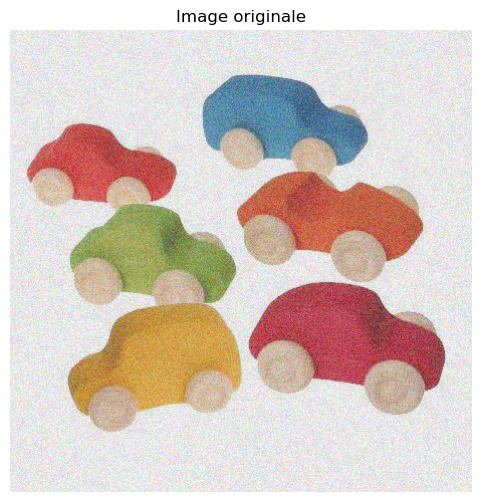

In [53]:
# Chargement de l'image
image = Image.open("wooden_cars_noisy.png")

# Conversion en tableau numpy
image_array = np.array(image)

# Dimensions de l'image
print("Dimensions de l'image :", image_array.shape)

# Affichage de l'image originale

plt.figure(figsize=(6,6))

plt.imshow(image_array)

plt.title("Image originale")
plt.axis("off")

plt.show()

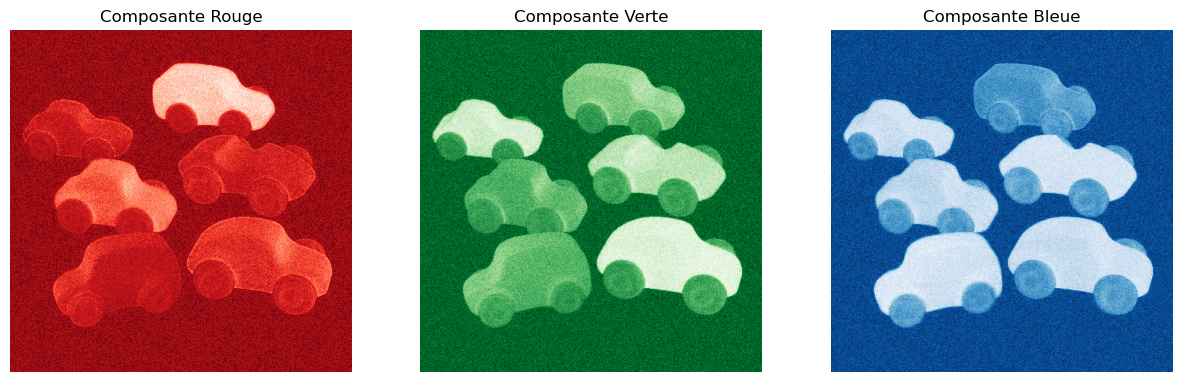

In [54]:
# Suppression du canal alpha
image_rgb = image_array[:, :, :3]

# Extraction des composantes RGB

R = image_rgb[:, :, 0]
G = image_rgb[:, :, 1]
B = image_rgb[:, :, 2]

# Affichage des composantes

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Composante Rouge")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Composante Verte")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Composante Bleue")
plt.axis("off")

plt.show()

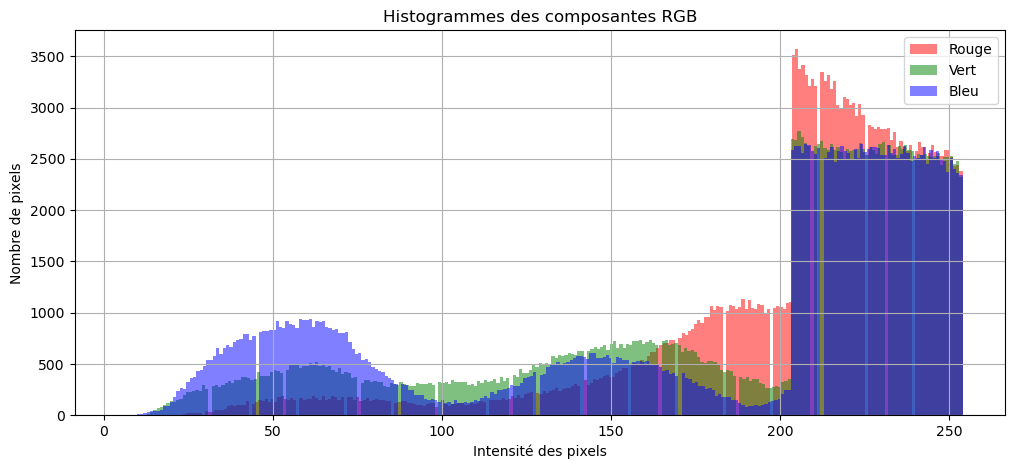

In [55]:
# Affichage des histogrammes RGB

plt.figure(figsize=(12,5))

plt.hist(R.ravel(), bins=256, color='red', alpha=0.5, label='Rouge')
plt.hist(G.ravel(), bins=256, color='green', alpha=0.5, label='Vert')
plt.hist(B.ravel(), bins=256, color='blue', alpha=0.5, label='Bleu')

plt.title("Histogrammes des composantes RGB")

plt.xlabel("Intensité des pixels")
plt.ylabel("Nombre de pixels")

plt.legend()
plt.grid()

plt.show()

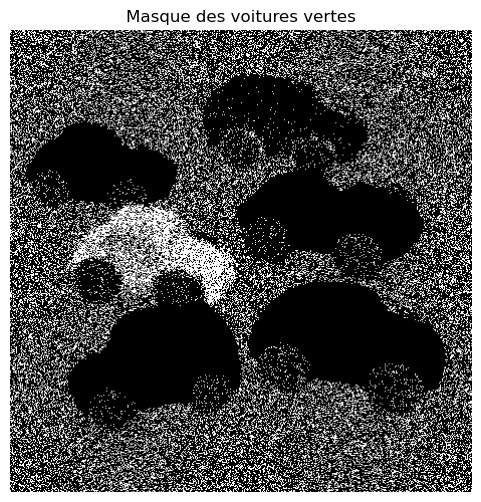

In [56]:
# Détection des pixels verts

mask_green = (
    (G > 90) &
    (G > R + 5) &
    (G > B + 5)
)

# Conversion en image binaire

mask_green = mask_green.astype(np.uint8)

# Affichage du masque

plt.figure(figsize=(6,6))

plt.imshow(mask_green, cmap='gray')

plt.title("Masque des voitures vertes")
plt.axis("off")

plt.show()

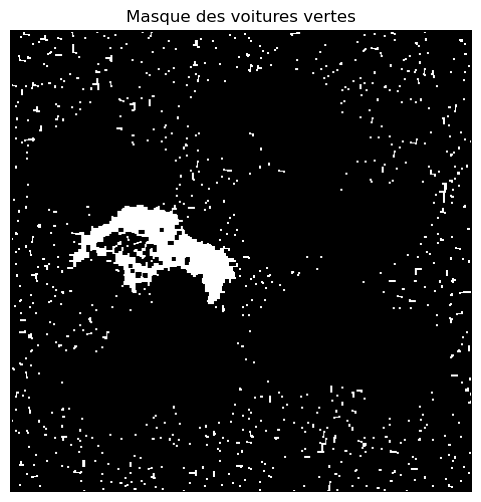

In [57]:
# Fonctions utilisées pour les opérations morphologiques
from scipy.ndimage import binary_opening, binary_closing

# Nettoyage du bruit

mask_clean = binary_opening(
    mask_green,
    structure=np.ones((2,2))
)

mask_clean = binary_closing(
    mask_clean,
    structure=np.ones((4,4))
)

# Affichage du masque nettoyé

plt.figure(figsize=(6,6))

plt.imshow(mask_clean, cmap='gray')

plt.title("Masque des voitures vertes")
plt.axis("off")

plt.show()

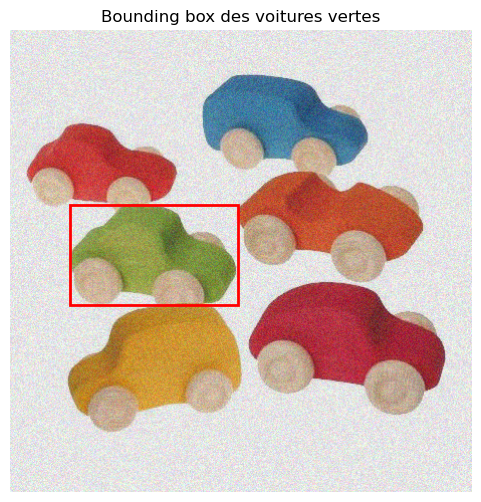

In [58]:
# Fonctions utilisées pour détecter les objets dans le masque
from scipy.ndimage import label, find_objects

# Bibliothèque utilisée pour tracer les rectangles
import matplotlib.patches as patches

# Détection des objets présents dans le masque

labeled_array, num_features = label(mask_clean)

objects = find_objects(labeled_array)

# Affichage de l'image originale

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(image_rgb)

# Parcours des objets détectés

for obj in objects:

    y_slice, x_slice = obj

    x_min = x_slice.start
    x_max = x_slice.stop

    y_min = y_slice.start
    y_max = y_slice.stop

    width = x_max - x_min
    height = y_max - y_min

    # Suppression des petites zones parasites

    if width > 20 and height > 20:

        rect = patches.Rectangle(
            (x_min, y_min),
            width,
            height,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

# Affichage final

ax.set_title("Bounding box des voitures vertes")
ax.axis("off")

plt.show()

# Conclusion

Dans ce projet, nous avons réalisé une segmentation couleur sur une image bruitée afin d’isoler les voitures vertes. Après séparation des composantes RGB et étude des histogrammes, un masque binaire a été créé puis nettoyé avec des opérations morphologiques. Enfin, les objets détectés ont été encadrés avec des bounding boxes.